Danielle Fischer
DSAN5550: Data Science For Climate Change

# Final Project: Modeling Climate Stress Impacts on U.S. Corn Yield: Evaluating Predictive Robustness and Regional Differences



## Building prototype with less data than final plan

### Data Prep:
* using weekly avg temp data from simpler dataset to make sure the pipeline works/ makes sense before diving into more complex prism data
* cleaning file: src/clean_data.py
* produced 3 clean csvs in data/clean/ : merged_model_data.csv, temperature_yearly.csv, and yield_cleaned.csv
* focusing on merged_model_data.csv, look closer into it to make sure everything looks right below
* preliminary plots to look @ data
* the cleaned dataset has county-level corn yield and average temperature data for Illinois, Iowa, Indiana, + Kansas from 2013-2022

In [ ]:
import pandas as pd

df = pd.read_csv("../data/prototype/clean/merged_model_data.csv")
df.head()

,state,county,county_clean,year,fips,yield_bu_acre,avg_temp
0,ILLINOIS,DE WITT,DE WITT,2022,17039,232.9,11.511656
1,ILLINOIS,LOGAN,LOGAN,2022,17107,229.1,11.673369
2,ILLINOIS,MACON,MACON,2022,17115,232.5,11.819814
3,ILLINOIS,MARSHALL,MARSHALL,2022,17123,221.7,10.857341
4,ILLINOIS,MASON,MASON,2022,17125,219.9,11.673217


In [6]:
df.shape

(3290, 7)

In [7]:
df.columns

Index(['state', 'county', 'county_clean', 'year', 'fips', 'yield_bu_acre',
       'avg_temp'],
      dtype='object')

In [8]:
df.groupby("state").size().reset_index(name="count")

,state,count
0,ILLINOIS,871
1,INDIANA,786
2,IOWA,934
3,KANSAS,699


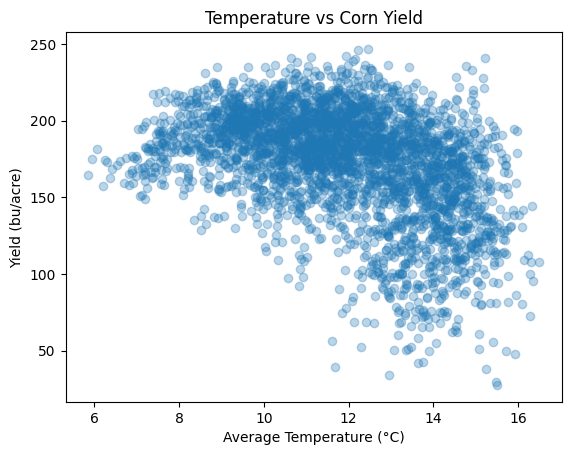

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df["avg_temp"], df["yield_bu_acre"], alpha=0.3)
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (bu/acre)")
plt.title("Temperature vs Corn Yield")
plt.show()

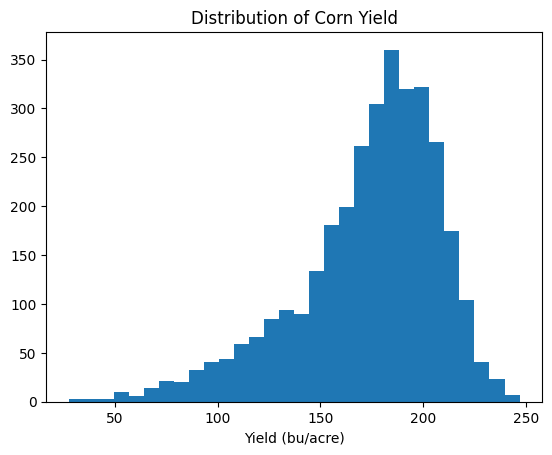

In [10]:
plt.hist(df["yield_bu_acre"], bins=30)
plt.title("Distribution of Corn Yield")
plt.xlabel("Yield (bu/acre)")
plt.show()

### Baseline model
* linear regression:
    * train on Corn Belt data (Iowa, Illinois, Indiana)
    * test out of region (Kansas)
* in file src/linear_model.py
    

In [ ]:
metrics = pd.read_csv("../outputs/prototype/linear_regression_metrics.csv")
metrics

,evaluation_set,rmse,mae,r2
0,corn_belt_cv,22.480825,17.728641,0.033720
1,kansas_transfer,62.394623,54.060815,-1.931449


the linear reg model shows limited predictive power when using temperature alone, with an R2 of approx. 0.03 within the Corn Belt, indicating that temperature explains only a small portion of yield variability (adding drought + precipitation data may help here)

Use 5-fold CV to train model on corn belt data

When applied to Kansas, model performance drops substantially, with w neg R2 value, indicating that the model performs worse than predicting the average yield. This relationship learned in Corn Belt did not generalize well to Kansas (limited test scope, will see how it does more widely)

Model coefficient indicates a negative relationship b/w temp and yield, higher temps are associated with lower yields

### Random Forest
* train/evaluate within region w/ cross validation on the corn belt
* test out-of-region on Kansas
* in file src/random_forest_model.py

In [ ]:
rf_metrics = pd.read_csv("../outputs/prototype/random_forest_metrics.csv")
rf_metrics

,evaluation_set,rmse,mae,r2
0,corn_belt_cv,22.167280,17.420246,0.060486
1,kansas_transfer,60.058969,51.290367,-1.716087


The RF model shows slight improvement over lin reg within the Corn Belt, R2 increasing from ~0.03 to ~0.06, nonlinear relationships gives some additional predictive power

overall performance still weak, temperature alone is not a strong predictor -- need to add others to see how trends change

on Kansas the model still does poorly, negative R2 value even with the more flexible model

so far reinforcing importance of feature selection

### Gradient Boost
* same structure as other two
* in file src/gradient_boost_model.py

In [ ]:
gb_metrics = pd.read_csv("../outputs/prototype/gradient_boost_metrics.csv")
gb_metrics

,evaluation_set,rmse,mae,r2
0,corn_belt_cv,21.970420,17.217618,0.077099
1,kansas_transfer,59.853252,51.251200,-1.697513


gradient boosting model gives the best performance (so far) among the three models, with R2 increasing to approx 0.08 within the Corn Belt
Boosting able to capture slightly more complex relationships b/w temp and yield
Kansas no better than other models, still negative

### All model comparison - just on temperature

In [ ]:
import pandas as pd

lin = pd.read_csv("../outputs/prototype/linear_regression_metrics.csv")
rf = pd.read_csv("../outputs/prototype/random_forest_metrics.csv")
gb = pd.read_csv("../outputs/prototype/gradient_boost_metrics.csv")

lin["model"] = "Linear"
rf["model"] = "Random Forest"
gb["model"] = "Gradient Boost"

all_metrics = pd.concat([lin, rf, gb])
all_metrics

,evaluation_set,rmse,mae,r2,model
0,corn_belt_cv,22.480825,17.728641,0.033720,Linear
1,kansas_transfer,62.394623,54.060815,-1.931449,Linear
0,corn_belt_cv,22.167280,17.420246,0.060486,Random Forest
1,kansas_transfer,60.058969,51.290367,-1.716087,Random Forest
0,corn_belt_cv,21.970420,17.217618,0.077099,Gradient Boost
1,kansas_transfer,59.853252,51.251200,-1.697513,Gradient Boost
